# Step 2: Outcome Modelling

## Libaries

In [69]:
from pathlib import Path
from pickle import dump, load
from pprint import pprint

import modules as geoint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Folders

Create folders for storing models and related data.

In [70]:
# Set folder for data and models
data_folder = '../../tmp/data'
model_folder = '../../tmp/models'
downloads_folder = '../../tmp/downloads'

# Create folders for model data
Path(data_folder).mkdir(parents=True, exist_ok=True)
Path(model_folder).mkdir(parents=True, exist_ok=True)

## Train AutoML Models

In [71]:
# Load toronto boundaries for clipping
city = gpd.read_file(f'{downloads_folder}/toronto.geojson')\
    .to_crs(32617)

# Train automl models
models = {}
geodata = {}
for size in [10, 40, 80]:
    
    # Load data
    print(f'Processing geogrid_to_{size}...')
    xraw = gpd.read_file(f'{data_folder}/geogrid_to_{size}.geojson')

    # Clip data
    xraw = xraw.clip(city)

    # Drop geometry and set outcome var
    x = pd.DataFrame(xraw.drop(columns='geometry'))
    ycol = 'collisions_count'
    geodata[f'geogrid_to_{size}'] = xraw
    
    # Columns to remove from input data
    startswith = ['collisions']
    
    # Drop columns except target col
    drop = [c for c in x.columns if any(c.startswith(s) for s in startswith) and c != ycol]
    x = x.drop(columns=drop)
    
    # Train autosklearn model
    ask_file = f'{model_folder}/autosklearn_{size}.pkl'
    if Path(ask_file).is_file():
        print(f'Model for autosklearn_{size} exists - skipping training...')
        with open(ask_file, 'rb') as f:
            ask = load(f)
    else:
        print(f'Training model for autosklearn_{size}...')
        ask = geoint.models.AutoMLModel('AutoSklearnRegressor')
        ask.fit(x=x, y=ycol)
        ask.predict()
        print(f'Saving model for autosklearn_{size}...')
        with open(ask_file, 'wb') as f:
            dump(ask, f)
    
    # Train tpot model
    tpt_file = f'{model_folder}/tpot_{size}.pkl'
    if Path(tpt_file).is_file():
        print(f'Model for tpot_{size} exists - skipping training...')
        tpt = geoint.models.AutoMLModel('TPOTRegressor')
        with open(tpt_file, 'rb') as f:
            tpt.model = load(f)
        tpt.last_x = x.drop(columns=ycol).select_dtypes('number').fillna(0)
        tpt.last_y = x[ycol]
        tpt.predict()
    else:
        print(f'Training model for tpot_{size}...')
        tpt = geoint.models.AutoMLModel('TPOTRegressor')
        tpt.fit(x=x, y=ycol) # if you get a runtime error, run this line in a separate cell, stop it, then try this code block again
        tpt.predict()
        print(f'Saving model for tpot_{size}...')
        with open(tpt_file, 'wb') as f:
            dump(tpt.model.fitted_pipeline_, f)
    
    # Store models
    models[f'autosklearn_{size}'] = ask
    models[f'tpot_{size}'] = tpt

print('Done!')

Processing geogrid_to_10...
Model for autosklearn_10 exists - skipping training...
Model for tpot_10 exists - skipping training...
Processing geogrid_to_40...
Model for autosklearn_40 exists - skipping training...
Model for tpot_40 exists - skipping training...
Processing geogrid_to_80...
Model for autosklearn_80 exists - skipping training...
Model for tpot_80 exists - skipping training...
Done!


Preview models:

In [72]:
pprint(models)

{'autosklearn_10': <modules.models.AutoMLModel object at 0x16b230730>,
 'autosklearn_40': <modules.models.AutoMLModel object at 0x167f6fe80>,
 'autosklearn_80': <modules.models.AutoMLModel object at 0x174a8b7c0>,
 'tpot_10': <modules.models.AutoMLModel object at 0x16b633850>,
 'tpot_40': <modules.models.AutoMLModel object at 0x1744cf280>,
 'tpot_80': <modules.models.AutoMLModel object at 0x1b870da60>}


## Calculate Model Scores

In [73]:
# Calc scores
scores = {'model': [], 'metric': [], 'score': []}
for name, m in models.items():
    
    # Default score
    scores['model'].append(name)
    scores['score'].append(m.score())
    scores['metric'].append(m.last_metric)
    
    # MAE score
    scores['model'].append(name)
    scores['score'].append(m.score(metric='mean_absolute_error'))
    scores['metric'].append('mean_absolute_error')
scores = pd.DataFrame(scores)

# Save scores
scores.to_csv(f'{model_folder}/scores.csv', index=False)

[Text(0, 0, '1241.93'),
 Text(0, 0, '979.63'),
 Text(0, 0, '203.61'),
 Text(0, 0, '131.66'),
 Text(0, 0, '105.88'),
 Text(0, 0, '82.95')]

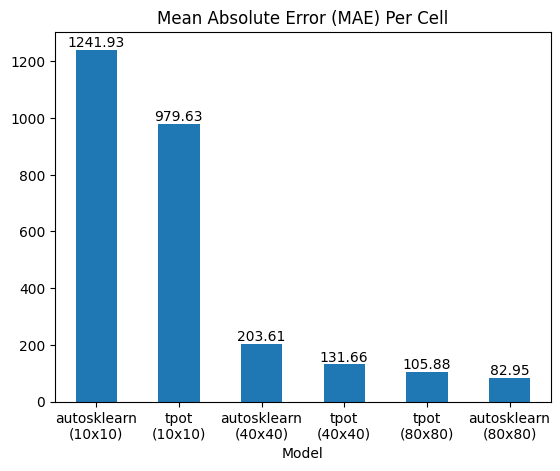

In [74]:
# Scores plot data
ax_data = scores[scores.metric == 'mean_absolute_error']\
    .sort_values(by='score', ascending=False)
ax_data['score'] = ax_data.score.round(2)
ax_data['model'] = ax_data.model\
    .str.replace('_10', '\n(10x10)')\
    .str.replace('_40', '\n(40x40)')\
    .str.replace('_80', '\n(80x80)')

# Plot scores
ax = ax_data.plot.bar(
    x='model',
    y='score',
    xlabel='Model',
    legend=False,
    title='Mean Absolute Error (MAE) Per Cell',
    rot=0
)
ax.bar_label(
    ax.containers[0],
    labels=ax_data.score.round(2)
)

In [75]:
ax_data

,model,metric,score
1,autosklearn\n(10x10),mean_absolute_error,1241.93
3,tpot\n(10x10),mean_absolute_error,979.63
5,autosklearn\n(40x40),mean_absolute_error,203.61
7,tpot\n(40x40),mean_absolute_error,131.66
11,tpot\n(80x80),mean_absolute_error,105.88
9,autosklearn\n(80x80),mean_absolute_error,82.95


In [68]:
print(sum(models['autosklearn_80'].predict(models['autosklearn_80'].last_x)))
print(sum(models['autosklearn_80'].last_predicted))
print(sum(models['autosklearn_80'].last_y))
print(sum(geodata['geogrid_to_80'][ycol]))

574406.4780416507
574406.4780416507
588876.0
588876.0


## Calculate Variable Importances

In [ ]:
# Determine best model
name = scores[(scores.metric == 'mean_absolute_error')]\
    .sort_values('score')\
    .iloc[0]\
    .model
name_full = name\
    .replace('_10', ' (10x10)')\
    .replace('_40', ' (40x40)')\
    .replace('_80', ' (80x80)')
m = models[name]

# Calc importances
importances_file = f'{model_folder}/importances.csv'
if Path(importances_file).is_file():

    # Skip calc and load importances
    print(f'Variable importances file exists - loading importances...')
    importances = pd.read_csv(importances_file)
    print('Done!')

else:
    
    # Prepare importance data
    importances = []
    print(f'Processing {name}...')
    imp_file = f'{model_folder}/{name}_importance.pkl'

    # Calculate var importances
    if Path(imp_file).is_file():
        print(f'Variable importances for {name} exists - loading...')
        with open(imp_file, 'rb') as f:
            imp = load(f) 
    else:
        print(f'Calculating variable importances for {name}...')
        imp = m.importance()
        with open(imp_file, 'wb') as f:
            dump(imp, f)

    # Combine importances
    importances = imp.sort_values(by='importance_mean', ascending=False)
    print('Done!')

    # Save importances
    importances.to_csv(importances_file, index=False)
    

Processing autosklearn_80...
Calculating variable importances for autosklearn_80...
Done!


<AxesSubplot:title={'center':'Variable Importance for autosklearn (80x80) Model'}, ylabel='Variable'>

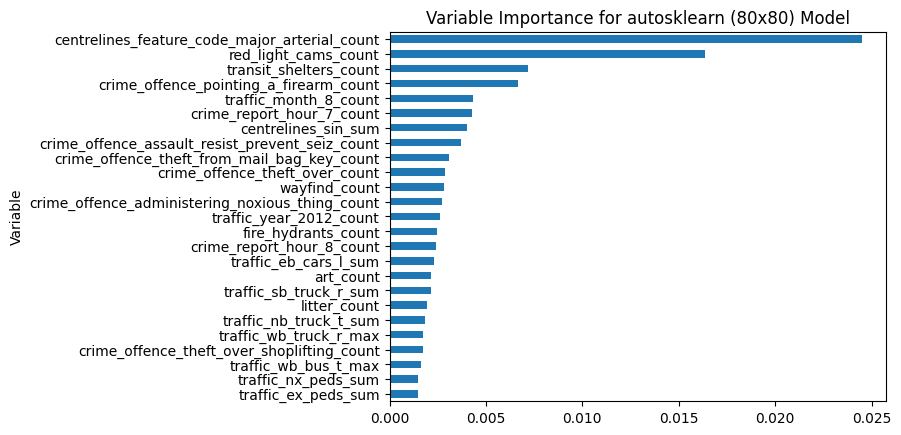

In [51]:
# Plot importances
importances\
    .nlargest(25, 'importance_mean')\
    .sort_values(by='importance_mean')\
    .plot.barh(
        x='variable',
        y='importance_mean',
        ylabel='Variable',
        title=f'Variable Importance for {name_full} Model',
        legend=False
    )

<AxesSubplot:title={'center':'Variable Importance for autosklearn (80x80) Model'}, ylabel='Infrastructure-related Variable'>

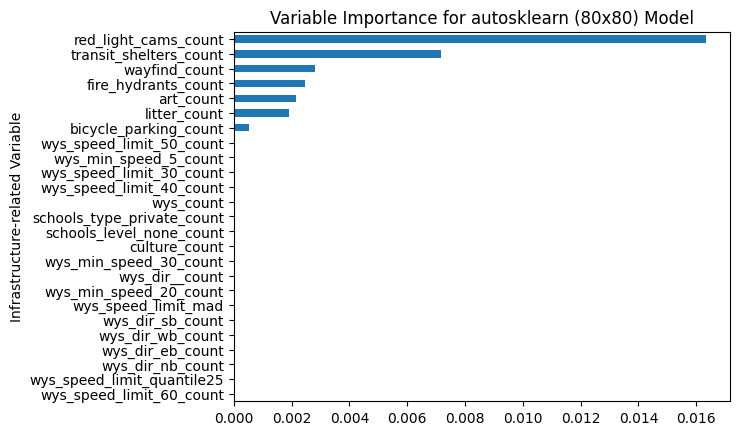

In [37]:
importances[
    ~importances.variable.str.startswith(('traffic', 'centrelines', 'crime'))
]\
    .nlargest(25, 'importance_mean')\
    .sort_values(by='importance_mean')\
    .plot.barh(
        x='variable',
        y='importance_mean',
        ylabel='Infrastructure-related Variable',
        title=f'Variable Importance for {name_full} Model',
        legend=False
    )

In [46]:
# Check hypothesis of pedestrian traffic to wayfinding
gcorr = geodata['geogrid_to_80'].corr()['wayfind_count'].sort_values()
gcorr[gcorr.notnull() & ((gcorr > 0.8) | (gcorr < -0.8))]

/var/folders/lg/1tfppccd38s1sn9w5z9g_mcm0000gn/T/ipykernel_6999/176115951.py:2: FutureWarning: The default value of numeric_only in GeoDataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  gcorr = geodata['geogrid_to_80'].corr()['wayfind_count'].sort_values()


traffic_ex_peds_mean    0.805018
traffic_ex_peds_max     0.810207
traffic_ex_peds_sum     0.825002
traffic_nx_peds_sum     0.827368
traffic_sx_peds_sum     0.840025
wayfind_count           1.000000
Name: wayfind_count, dtype: float64